In [ ]:
import os
import glob
import pandas as pd
from tqdm import tqdm

input_dir = "./outputs/harmonization/"

search_pattern = os.path.join(input_dir, "**", "*radiomics.csv")
csv_files = glob.glob(search_pattern, recursive=True)

assert csv_files, "Aucun fichier CSV de radiomiques trouvé dans le répertoire spécifié."
    
print(f"📄 {len(csv_files)} fichiers trouvés. Début de la lecture...")

df_list = []
for file_path in tqdm(csv_files, desc="Lecture ..."):
    df = pd.read_csv(file_path)
    
    if df.empty: 
        continue
    
    parts = os.path.normpath(file_path).split(os.sep)
    
    # structure du dossier output que j'ai préalablement définie
    if len(parts) >= 4:
        domain = parts[ -4 ]
        
        if "_to_" in domain: # stargan
            domain_source, domain_target = domain.split("_to_", 1)
        else: # harmonisation std
            domain_source, domain_target = domain, None
            
        # Insertion des métadonnées contextuelles au début du DataFrame
        df.insert(0, 'Domain_Target', domain_target)
        df.insert(0, 'Domain_Source', domain_source)
        df.insert(0, 'Domain', domain)
    else:
        df.insert(0, 'Source_Path', os.path.dirname(file_path))
    
    df_list.append(df)
        

assert df_list, "Aucun DataFrame valide n'a été créé à partir des fichiers CSV"

print("🔗 Concaténation des DataFrames...")
master_df = pd.concat(df_list, ignore_index=True)

print("="*50)
print("✅ FUSION TERMINÉE AVEC SUCCÈS")
print("="*50)
print(f"Total des lignes  : {len(master_df)}")
print(f"Total des colonnes: {len(master_df.columns)}")
print("="*50)

# master_df.head()

save_path = 'data/master_radiomics.csv'
master_df.to_csv(save_path, index=False)
print(f"💾 DataFrame fusionné sauvegardé sous : {save_path}")

📄 375 fichiers trouvés. Début de la lecture...


Lecture ...: 100%|██████████| 375/375 [00:01<00:00, 350.29it/s]

🔗 Concaténation des DataFrames...
✅ FUSION TERMINÉE AVEC SUCCÈS
Total des lignes  : 750
Total des colonnes: 101


,Domain,Domain_Source,Domain_Target,Subject_ID,VOI,Modality,Image_Filename,ROI_type,original_firstorder_10Percentile,original_firstorder_90Percentile,...,original_gldm_LargeDependenceLowGrayLevelEmphasis,original_gldm_LowGrayLevelEmphasis,original_gldm_SmallDependenceEmphasis,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength
0,nantes,nantes,None,15080000,liver,harmonized,vae.nii.gz,Sphere_20.0mm,1.911459,2.212969,...,62.775699,0.159397,0.004766,0.039991,0.000861,29.159120,0.002887,1.284328,0.011256,0.015626
1,nantes,nantes,None,15080000,liver,standard,source_cropped.nii.gz,Sphere_20.0mm,2.178105,2.912618,...,6.201635,0.059041,0.024455,0.624618,0.002068,8.223947,0.002482,17.024284,0.018902,0.071017
2,nantes,nantes,None,13250000,liver,harmonized,vae.nii.gz,Sphere_20.0mm,1.526373,1.800982,...,104.608591,0.266349,0.004306,0.023994,0.001395,35.651290,0.002899,1.261954,0.008647,0.016329
3,nantes,nantes,None,13250000,liver,standard,source_cropped.nii.gz,Sphere_20.0mm,1.399582,1.906235,...,11.923378,0.070047,0.017445,0.333323,0.001760,12.458307,0.002309,8.385329,0.014138,0.039566
4,nantes,nantes,None,8280000,liver,harmonized,vae.nii.gz,Sphere_20.0mm,2.363982,2.765342,...,26.326924,0.080954,0.006327,0.086382,0.000717,18.197376,0.002652,2.897425,0.012243,0.028398


In [2]:
# read csv
import pandas as pd
master_df = pd.read_csv('./master_radiomics.csv')
master_df

,Domain,Domain_Source,Domain_Target,Subject_ID,VOI,Component,Modality,Image_Filename,ROI_type,original_firstorder_10Percentile,...,original_gldm_LargeDependenceLowGrayLevelEmphasis,original_gldm_LowGrayLevelEmphasis,original_gldm_SmallDependenceEmphasis,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength
0,curie,curie,NaN,2077,liver,NaN,pet,pet.nii.gz,Sphere_20.0mm,1.918541,...,5.158041,0.054021,0.026286,0.857736,0.001630,5.921439,0.003189,20.221136,0.025901,0.103394
1,curie,curie,NaN,2089,liver,NaN,pet,pet.nii.gz,Sphere_20.0mm,3.767481,...,9.542391,0.079232,0.018221,0.539289,0.001297,5.396629,0.004347,15.440477,0.026623,0.144993
2,curie,curie,NaN,2055,liver,NaN,pet,pet.nii.gz,Sphere_20.0mm,1.436280,...,36.793217,0.128431,0.008917,0.095788,0.001280,23.780950,0.002498,2.929520,0.013339,0.020916
3,curie,curie,NaN,2054,liver,NaN,pet,pet.nii.gz,Sphere_20.0mm,2.609889,...,8.431511,0.071717,0.020897,0.562183,0.001662,6.892292,0.003333,13.806599,0.025991,0.087131
4,curie,curie,NaN,2059,liver,NaN,pet,pet.nii.gz,Sphere_20.0mm,2.680077,...,5.130676,0.028714,0.012416,0.571284,0.000420,2.870034,0.003208,21.722024,0.007311,0.229073
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24460,lacassagne,lacassagne,NaN,1205,liver,NaN,pet,pet.nii.gz,Sphere_20.0mm,2.837308,...,46.434539,0.168494,0.007861,0.097007,0.001310,17.700631,0.003225,4.068512,0.018296,0.041290
24461,lacassagne,lacassagne,NaN,1205,liver,NaN,harmonized-pet-vae,harmonized-pet-vae.nii.gz,Sphere_20.0mm,2.381095,...,19.468959,0.063631,0.006899,0.192288,0.000416,6.453534,0.004419,6.939989,0.015738,0.099768
24462,lacassagne,lacassagne,NaN,1019,liver,NaN,pet,pet.nii.gz,Sphere_20.0mm,1.399775,...,33.008380,0.147362,0.010963,0.135382,0.001835,20.891641,0.002245,5.438372,0.012519,0.031723
24463,lacassagne,lacassagne,NaN,1044,liver,NaN,pet,pet.nii.gz,Sphere_20.0mm,2.303190,...,5.381608,0.044736,0.019502,0.667495,0.000918,5.006925,0.003121,17.714086,0.015118,0.114285


In [3]:
import pandas as pd

# req_mods = ['pet', 'harmonized-pet-vae', 'harmonized-pet-standard-vae', 'gaussian-earl1']
req_mods = ['pet', 'harmonized-pet-vae']

df_filtered = master_df[master_df['Modality'].isin(req_mods)]

mod_counts = df_filtered.groupby('Subject_ID')['Modality'].nunique()
valid_patients = mod_counts[mod_counts == len(req_mods)].index

master_df = df_filtered[df_filtered['Subject_ID'].isin(valid_patients)]
master_df

,Domain,Domain_Source,Domain_Target,Subject_ID,VOI,Component,Modality,Image_Filename,ROI_type,original_firstorder_10Percentile,...,original_gldm_LargeDependenceLowGrayLevelEmphasis,original_gldm_LowGrayLevelEmphasis,original_gldm_SmallDependenceEmphasis,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength
4,curie,curie,NaN,2059,liver,NaN,pet,pet.nii.gz,Sphere_20.0mm,2.680077,...,5.130676,0.028714,0.012416,0.571284,0.000420,2.870034,0.003208,21.722024,0.007311,0.229073
5,curie,curie,NaN,2059,liver,NaN,harmonized-pet-vae,harmonized-pet-vae.nii.gz,Sphere_20.0mm,2.423744,...,9.414205,0.038757,0.006493,0.194888,0.000364,4.083816,0.004007,9.368512,0.009985,0.138057
7,curie,curie,NaN,2028,liver,NaN,pet,pet.nii.gz,Sphere_20.0mm,1.598015,...,35.160076,0.160430,0.010045,0.109152,0.002512,13.681887,0.003076,6.655949,0.013944,0.064376
8,curie,curie,NaN,2028,liver,NaN,harmonized-pet-vae,harmonized-pet-vae.nii.gz,Sphere_20.0mm,1.522401,...,98.529608,0.265107,0.004250,0.022616,0.001537,37.610238,0.003051,1.211789,0.012268,0.016250
9,curie,curie,NaN,2097,liver,NaN,pet,pet.nii.gz,Sphere_20.0mm,1.606856,...,25.620718,0.147915,0.015627,0.250779,0.002612,11.586455,0.003047,10.658608,0.017730,0.081697
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24455,lacassagne,lacassagne,NaN,1005,liver,NaN,harmonized-pet-vae,harmonized-pet-vae.nii.gz,Sphere_20.0mm,2.315204,...,72.037462,0.204820,0.005093,0.053405,0.001162,13.349578,0.003693,5.330823,0.012343,0.092729
24457,lacassagne,lacassagne,NaN,1139,liver,NaN,pet,pet.nii.gz,Sphere_20.0mm,1.692219,...,8.552111,0.056178,0.016044,0.438061,0.001399,5.689792,0.003092,17.179346,0.012741,0.129223
24458,lacassagne,lacassagne,NaN,1139,liver,NaN,harmonized-pet-vae,harmonized-pet-vae.nii.gz,Sphere_20.0mm,1.613666,...,63.767936,0.162942,0.004674,0.048334,0.000862,23.235882,0.003434,2.148995,0.014377,0.029454
24460,lacassagne,lacassagne,NaN,1205,liver,NaN,pet,pet.nii.gz,Sphere_20.0mm,2.837308,...,46.434539,0.168494,0.007861,0.097007,0.001310,17.700631,0.003225,4.068512,0.018296,0.041290


## Kruskall-Wallis Test

In [4]:
import pandas as pd
from scipy.stats import kruskal

df_std = master_df[master_df['Modality'] == 'pet'].copy()
df_harm = master_df[master_df['Modality'] == 'harmonized-pet-vae'].copy()

domains_list = list(master_df['Domain_Source'].dropna().unique())

results = []
features = [col for col in master_df.columns if col.startswith('original_') and not col.startswith('original_shape_')]

print(f"🚀 Audit d'harmonisation sur {len(features)} features")
print(f"Centres comparés : {domains_list}")

for feat in features:
    groups_std = [df_std[df_std['Domain_Source'] == d][feat].dropna().values for d in domains_list]
    groups_harm = [df_harm[df_harm['Domain_Source'] == d][feat].dropna().values for d in domains_list]
    
    if all(len(g) > 0 for g in groups_std) and all(len(g) > 0 for g in groups_harm):
        # Kruskal-Wallis pour mesurer l'écart inter-centres
        h_std, p_std = kruskal(*groups_std)
        h_harm, p_harm = kruskal(*groups_harm)
        
        # Calcul de l'amélioration (pourcentage de réduction de la stat H)
        if h_std > 0:
            improvement_pct = ((h_std - h_harm) / h_std) * 100
        else:
            improvement_pct = 0.0
            
        results.append({
            'Feature': feat,
            'H_Standard (Biais)': round(h_std, 1),
            'H_Harmonized (Biais)': round(h_harm, 1),
            'Amélioration (%)': round(improvement_pct, 1)
        })

kw_results = pd.DataFrame(results)
total_features = len(kw_results)

if total_features > 0:
    improved_features = len(kw_results[kw_results['Amélioration (%)'] > 0])
    worsened_features = total_features - improved_features

    print("\n" + "="*60)
    print("📈 BILAN GLOBAL DE L'HARMONISATION")
    print("="*60)
    print(f"✔️ Features améliorées (Biais réduit) : {improved_features} / {total_features} ({(improved_features/total_features)*100:.1f}%)")
    print(f"❌ Features dégradées (Biais augmenté) : {worsened_features} / {total_features}")

    # --- TOP 30 DES MEILLEURES AMÉLIORATIONS ---
    df_top30 = kw_results.sort_values(by='Amélioration (%)', ascending=False)# .head(30)

    print("\n" + "="*80)
    print("🏆 TOP 30 DES FEATURES LES PLUS HARMONISÉES PAR TON MODÈLE")
    print("="*80)
    print(df_top30.to_string(index=False))
else:
    print("\n⚠️ Impossible de calculer Kruskal-Wallis. Vérifie que tu as au moins 2 centres avec des données standard ET harmonized.")

🚀 Audit d'harmonisation sur 93 features
Centres comparés : ['curie', 'nantes', 'rennes', 'a100', 'chb', 'lacassagne']

📈 BILAN GLOBAL DE L'HARMONISATION
✔️ Features améliorées (Biais réduit) : 92 / 93 (98.9%)
❌ Features dégradées (Biais augmenté) : 1 / 93

🏆 TOP 30 DES FEATURES LES PLUS HARMONISÉES PAR TON MODÈLE
                                           Feature  H_Standard (Biais)  H_Harmonized (Biais)  Amélioration (%)
                      original_firstorder_Skewness                96.7                  10.5              89.2
                  original_glszm_SmallAreaEmphasis               245.3                  76.5              68.8
                         original_glcm_Correlation               438.3                 167.4              61.8
                   original_glrlm_ShortRunEmphasis               331.1                 128.3              61.3
   original_glrlm_RunLengthNonUniformityNormalized               332.7                 132.0              60.3
                   

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.stats import gaussian_kde
    
def display_pca(df_std, df_harm, df_top_features):
    features = df_top_features['Feature'].tolist()
    X_std_raw = df_std[features].values
    X_harm_raw = df_harm[features].values

    # --- 1. TRAITEMENT DES OUTLIERS & SCALING ---
    low, high = np.percentile(X_std_raw, [0.5, 99.5], axis=0)
    X_std_clipped = np.clip(X_std_raw, low, high)
    X_harm_clipped = np.clip(X_harm_raw, low, high)

    scaler = StandardScaler()
    X_std_scaled = scaler.fit_transform(X_std_clipped)
    X_harm_scaled = scaler.transform(X_harm_clipped)

    # --- 2. CALCUL PCA ---
    pca = PCA(n_components=2)
    pca_std = pca.fit_transform(X_std_scaled)
    pca_harm = pca.transform(X_harm_scaled)

    df_std['PC1'], df_std['PC2'] = pca_std[:, 0], pca_std[:, 1]
    df_harm['PC1'], df_harm['PC2'] = pca_harm[:, 0], pca_harm[:, 1]

    # --- 3. CALCUL DES LIMITES GLOBALES (CORRECTION ICI) ---
    # On concatène les résultats des deux pour trouver les frontières communes
    all_pc1 = pd.concat([df_std['PC1'], df_harm['PC1']])
    all_pc2 = pd.concat([df_std['PC2'], df_harm['PC2']])

    # On prend 0.5% de marge pour ignorer les outliers extrêmes tout en voyant tout le monde
    x_min, x_max = np.percentile(all_pc1, [0.5, 99.5])
    y_min, y_max = np.percentile(all_pc2, [0.5, 99.5])
    
    # Ajout d'une marge de confort (20%)
    margin_x = (x_max - x_min) * 0.2
    margin_y = (y_max - y_min) * 0.2
    
    final_xlim = (x_min - margin_x, x_max + margin_x)
    final_ylim = (y_min - margin_y, y_max + margin_y)

    # --- 4. VISUALISATION ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
    palette = {
        'a100': '#E6194B',       # Rouge vif
        'chb': '#4363D8',        # Bleu roi intense
        'rennes': '#3CB44B',     # Vert franc
        'nice': '#F032E6',       # Magenta éclatant
        'nantes': '#F58231',     # Orange pur
        'curie': '#911EB4',      # Violet profond
        'lacassagne': '#00CED1'  # Cyan lumineux (DarkTurquoise)
    }

    plots = [
        (df_std, "1. PET Standard (Baseline)", 'o'), 
        (df_harm, "2. PET Harmonized (Projection)", 's')
    ]

    for i, (df, title, marker) in enumerate(plots):
        sns.scatterplot(
            data=df, x='PC1', y='PC2', hue='Domain', 
            palette=palette, ax=axes[i], s=30, alpha=0.7, 
            edgecolor='black', marker=marker, linewidth=0.6
        )
        
        # Application des limites globales synchronisées
        axes[i].set_xlim(final_xlim)
        axes[i].set_ylim(final_ylim)
        
        axes[i].set_title(title, fontsize=14, fontweight='bold')
        axes[i].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
        axes[i].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)" if i==0 else "")
        axes[i].grid(True, linestyle=':', alpha=0.4)

    plt.suptitle("Analyse PCA : Convergence des centres après Harmonisation", 
                 fontsize=16, y=1.02, fontweight='black')
    plt.tight_layout()
    plt.show()


def display_umap(n, dist, df_std, df_harm, df_top_features):
    features = df_top_features['Feature'].tolist() 
    X_std = df_std[features].values
    X_harm = df_harm[features].values

    # =========================================================
    # 3. Z-SCORE ET UMAP (Fit sur Standard, Transform sur Harmonized)
    # =========================================================
    # Normalisation calquée sur le Standard
    scaler = StandardScaler()
    X_std_scaled = scaler.fit_transform(X_std)
    X_harm_scaled = scaler.transform(X_harm)

    # UMAP : Apprentissage du biais sur le Standard
    reducer = umap.UMAP(n_neighbors=n, min_dist=dist, random_state=42, metric="euclidean")
    umap_std = reducer.fit_transform(X_std_scaled)
    umap_harm = reducer.transform(X_harm_scaled)

    df_std['UMAP_1'], df_std['UMAP_2'] = umap_std[:, 0], umap_std[:, 1]
    df_harm['UMAP_1'], df_harm['UMAP_2'] = umap_harm[:, 0], umap_harm[:, 1]

    # =========================================================
    # 4. VISUALISATION AVANT / APRÈS
    # =========================================================
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

    # Palette correspondant à tes domaines
    palette = {
        'a100': '#E6194B',       # Rouge vif
        'chb': '#4363D8',        # Bleu roi intense
        'rennes': '#3CB44B',     # Vert franc
        'nice': '#F032E6',       # Magenta éclatant
        'nantes': '#F58231',     # Orange pur
        'curie': '#911EB4',      # Violet profond
        'lacassagne': '#00CED1'  # Cyan lumineux (DarkTurquoise)
    }

    # Graphe 1 : PET Standard
    sns.scatterplot(
        data=df_std, x='UMAP_1', y='UMAP_2', hue='Domain', 
        palette=palette, ax=axes[0], s=80, alpha=0.8, edgecolor='black'
    )
    axes[0].set_title("1. PET Standard (Validation Set)\nClusters par centre visibles", fontsize=14, fontweight='bold')
    axes[0].grid(True, linestyle=':', alpha=0.5)

    # Graphe 2 : PET Harmonized (Ton modèle)
    sns.scatterplot(
        data=df_harm, x='UMAP_1', y='UMAP_2', hue='Domain', 
        palette=palette, ax=axes[1], s=80, alpha=0.8, edgecolor='black', marker='s'
    )
    axes[1].set_title("2. PET Harmonized (Projection)\nConvergence et mélange des centres", fontsize=14, fontweight='bold')
    axes[1].grid(True, linestyle=':', alpha=0.5)

    plt.suptitle("Évaluation de l'Harmonisation (All Features)", fontsize=18, y=1.02, fontweight='black')
    plt.tight_layout()
    plt.show()


def display_tsne(df_std, df_harm, df_top_features, perplexity = 30):
    features = df_top_features['Feature'].tolist()
    X_std_raw = df_std[features].values
    X_harm_raw = df_harm[features].values

    # On garde le clipping pour éviter que l'outlier ne fausse l'initialisation PCA du t-SNE
    low, high = np.percentile(X_std_raw, [1, 99], axis=0)
    X_std_clipped = np.clip(X_std_raw, low, high)
    X_harm_clipped = np.clip(X_harm_raw, low, high)

    scaler = StandardScaler()
    X_std_scaled = scaler.fit_transform(X_std_clipped)
    X_harm_scaled = scaler.transform(X_harm_clipped)

    # --- 2. t-SNE GLOBAL (Fit sur Standard + Harmonized) ---
    X_combined = np.vstack((X_std_scaled, X_harm_scaled))

    print(f"Calcul du t-SNE sur {len(X_combined)} points (Perplexity=30)...")

    # Paramètres optimisés pour 195 points
    tsne = TSNE(
        n_components=2, 
        perplexity=perplexity, 
        random_state=42, 
        init='pca', 
        learning_rate='auto'
    )

    tsne_results = tsne.fit_transform(X_combined)

    # Séparation des coordonnées pour l'affichage
    n_std = len(X_std_raw)
    df_std['TSNE1'], df_std['TSNE2'] = tsne_results[:n_std, 0], tsne_results[:n_std, 1]
    df_harm['TSNE1'], df_harm['TSNE2'] = tsne_results[n_std:, 0], tsne_results[n_std:, 1]

    # --- 3. VISUALISATION ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
    palette = {
        'a100': '#E6194B',       # Rouge vif
        'chb': '#4363D8',        # Bleu roi intense
        'rennes': '#3CB44B',     # Vert franc
        'nice': '#F032E6',       # Magenta éclatant
        'nantes': '#F58231',     # Orange pur
        'curie': '#911EB4',      # Violet profond
        'lacassagne': '#00CED1'  # Cyan lumineux (DarkTurquoise)
    }

    for i, (df, title, marker) in enumerate([(df_std, "PET Standard", 'o'), (df_harm, "PET Harmonized", 's')]):
        sns.scatterplot(
            data=df, x='TSNE1', y='TSNE2', hue='Domain', 
            palette=palette, ax=axes[i], s=55, alpha=0.8, edgecolor='black', marker=marker, linewidth=0.6
        )
        
        axes[i].set_title(f"{title}", fontsize=14, fontweight='bold')
        axes[i].set_xlabel("t-SNE dimension 1")
        axes[i].set_ylabel("t-SNE dimension 2" if i==0 else "")
        axes[i].grid(True, linestyle=':', alpha=0.4)

    plt.suptitle("Validation t-SNE : Harmonisation des domaines (Standard vs U-Net)", fontsize=16, y=1.02, fontweight='black')
    plt.tight_layout()
    plt.show()
    

def calculate_ovl(data_dict, n_points=1000):
    if len(data_dict) < 2: return 0.0
    all_vals = np.concatenate(list(data_dict.values()))
    if len(all_vals) < 2: return 0.0
    # Plage d'intégration basée sur les données réelles
    x = np.linspace(all_vals.min(), all_vals.max(), n_points)
    try:
        densities = [gaussian_kde(d)(x) for d in data_dict.values() if len(d) > 1]
        if not densities: return 0.0
        return np.trapz(np.minimum.reduce(densities), x) * 100
    except:
        return 0.0

def display_cov(df_all):
    # --- 1. CALCUL DES MÉTRIQUES SUR LA TOTALITÉ ---
    df_all['COV'] = np.sqrt(df_all['original_firstorder_Variance']) / df_all['original_firstorder_Mean']
    df_all['Entropy'] = df_all['original_firstorder_Entropy']

    if 'original_firstorder_InterquartileRange' in df_all.columns and 'original_firstorder_Median' in df_all.columns:
        df_all['Robust_COV'] = df_all['original_firstorder_InterquartileRange'] / df_all['original_firstorder_Median']
    else:
        df_all['Robust_COV'] = df_all['original_firstorder_MeanAbsoluteDeviation'] / df_all['original_firstorder_Median']

    # --- 3. PRÉPARATION GLOBALE (SANS ÉCHANTILLONNAGE) ---
    domains = sorted(df_all['Domain'].unique())
    modalities = ['PET_Standard', 'PET_EARL', 'PET_Harmonized']
    metrics = ['COV', 'Entropy', 'Robust_COV']
    metric_labels = ['COV ($\sigma / \mu$)', 'Entropie (Complexité)', 'Robust COV ($IQR / Median$)']

    # On utilise l'intégralité du DataFrame pour l'affichage
    df_plot = df_all.copy()

    # Pré-calcul des limites par colonne basées sur les 195 patients (1% / 99%)
    column_limits = {}
    for met in metrics:
        p1, p99 = np.percentile(df_plot[met].dropna(), [1, 99])
        margin = (p99 - p1) * 0.1
        column_limits[met] = (p1 - margin, p99 + margin)

    # --- 4. TRACÉ DE LA MATRICE 3x3 ---
    fig, axes = plt.subplots(3, 3, figsize=(22, 18))
    palette = {
        'a100': '#E6194B',       # Rouge vif
        'chb': '#4363D8',        # Bleu roi intense
        'rennes': '#3CB44B',     # Vert franc
        'nice': '#F032E6',       # Magenta éclatant
        'nantes': '#F58231',     # Orange pur
        'curie': '#911EB4',      # Violet profond
        'lacassagne': '#00CED1'  # Cyan lumineux (DarkTurquoise)
    }

    for row, mod in enumerate(modalities):
        for col, met in enumerate(metrics):
            ax = axes[row, col]
            df_mod = df_plot[df_plot['Modality'] == mod]
            
            # Bornes globales pour le filtrage des outliers
            p1_global, p99_global = np.percentile(df_plot[met].dropna(), [1, 99])
            
            dist_data = {}
            for d in domains:
                vals = df_mod[df_mod['Domain'] == d][met].dropna().values
                # Filtrage des percentiles extrêmes pour la clarté visuelle
                filtered_vals = vals[(vals >= p1_global) & (vals <= p99_global)]
                if len(filtered_vals) > 0:
                    dist_data[d] = filtered_vals

            # Calcul de l'overlap sur la population totale filtrée
            ovl_score = calculate_ovl(dist_data)
            
            # Affichage des courbes KDE
            for d, vals in dist_data.items():
                sns.kdeplot(vals, ax=ax, fill=True, color=palette[d], 
                            label=f"{d} (n={len(vals)})", alpha=0.3, linewidth=2)
                # Ligne verticale sur la Médiane
                ax.axvline(np.median(vals), color=palette[d], linestyle='--', alpha=0.8)
            
            # Verrouillage des axes X par métrique
            ax.set_xlim(column_limits[met])
            
            # Annotations et style
            if col == 0: ax.set_ylabel(f"{mod.replace('_', ' ')}\n\nDensité", fontsize=12, fontweight='bold')
            if row == 0: ax.set_title(metric_labels[col], fontsize=14, pad=20, fontweight='black')
            
            ax.text(0.95, 0.95, f"OVL: {ovl_score:.1f}%", transform=ax.transAxes, 
                    ha='right', va='top', fontsize=11, fontweight='bold', 
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))
            
            ax.grid(axis='y', linestyle=':', alpha=0.4)
            if row == 2: ax.set_xlabel(metric_labels[col])

    plt.suptitle("Audit de l'Harmonisation Radiomique (Population Totale - 195 Patients)", 
                fontsize=22, y=1.02, fontweight='black')
    plt.tight_layout()
    plt.show()


Nombre de features sélectionnées : 93


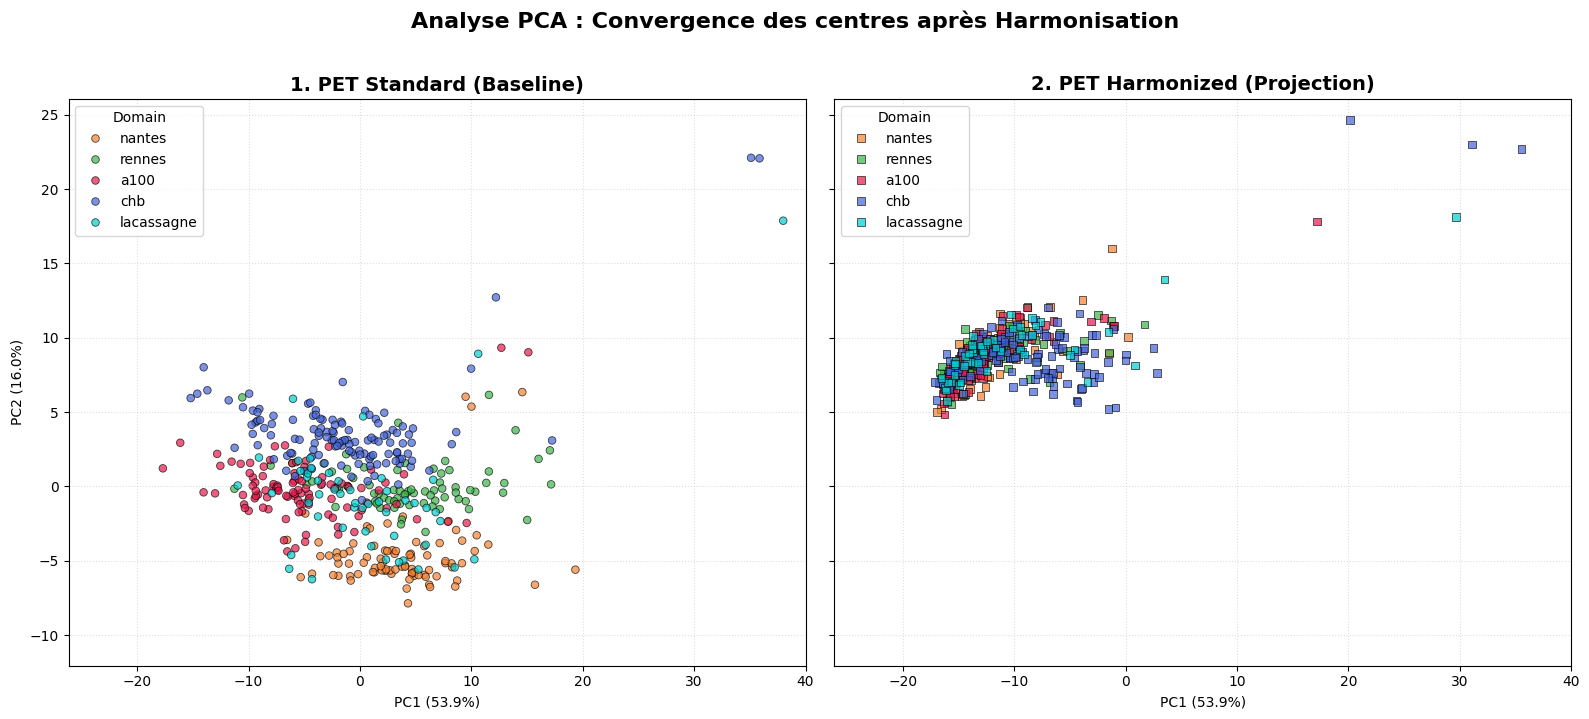

In [6]:
features = df_top30['Feature'].tolist()

selected_features = df_top30[df_top30['Feature'].isin(features)].copy()
print(f"Nombre de features sélectionnées : {len(features)}")

voi_master_df = master_df[(master_df['VOI'] == 'liver') & (master_df['Domain'].isin(['nantes', 'lacassagne', 'rennes', 'a100', 'chb', 'nice']))]

df_std = voi_master_df[voi_master_df['Modality'] == 'pet'].copy()
df_harm = voi_master_df[voi_master_df['Modality'] == 'harmonized-pet-vae'].copy()

display_pca(df_std, df_harm, selected_features)

Nombre de features sélectionnées : 30


c:\Users\aghil\miniconda3\envs\work\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


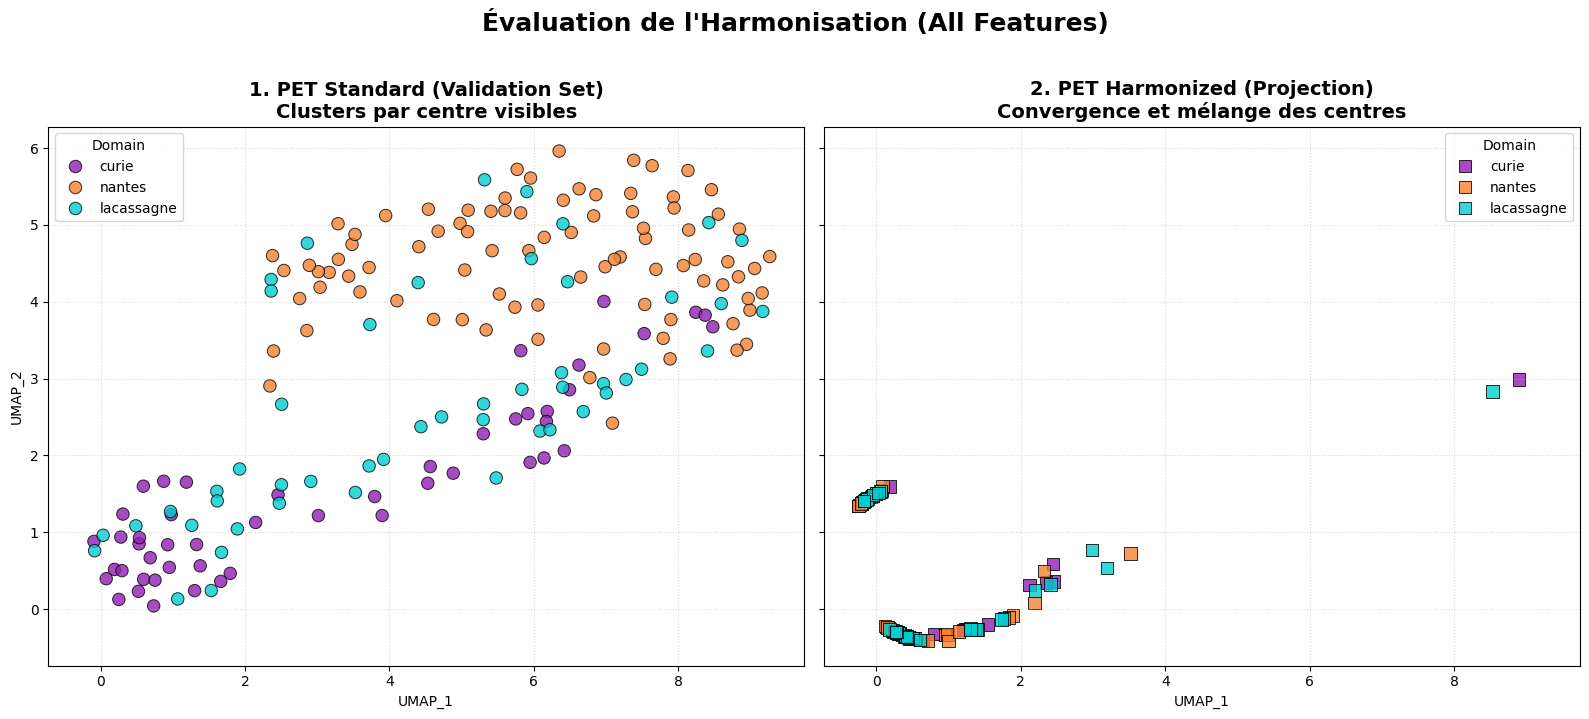

In [18]:
features = df_top30['Feature'].tolist()

selected_features = df_top30[df_top30['Feature'].isin(features)].copy()
print(f"Nombre de features sélectionnées : {len(features)}")

voi_master_df = master_df[(master_df['VOI'] == 'liver') & (master_df['Domain'].isin(['nantes', 'curie', 'lacassagne']))]

df_std = voi_master_df[voi_master_df['Modality'] == 'pet'].copy()
df_harm = voi_master_df[voi_master_df['Modality'] == 'harmonized-pet-vae'].copy()

display_umap(30, 0.3, df_std, df_harm, selected_features)

Nombre de features sélectionnées : 30
Calcul du t-SNE sur 372 points (Perplexity=30)...


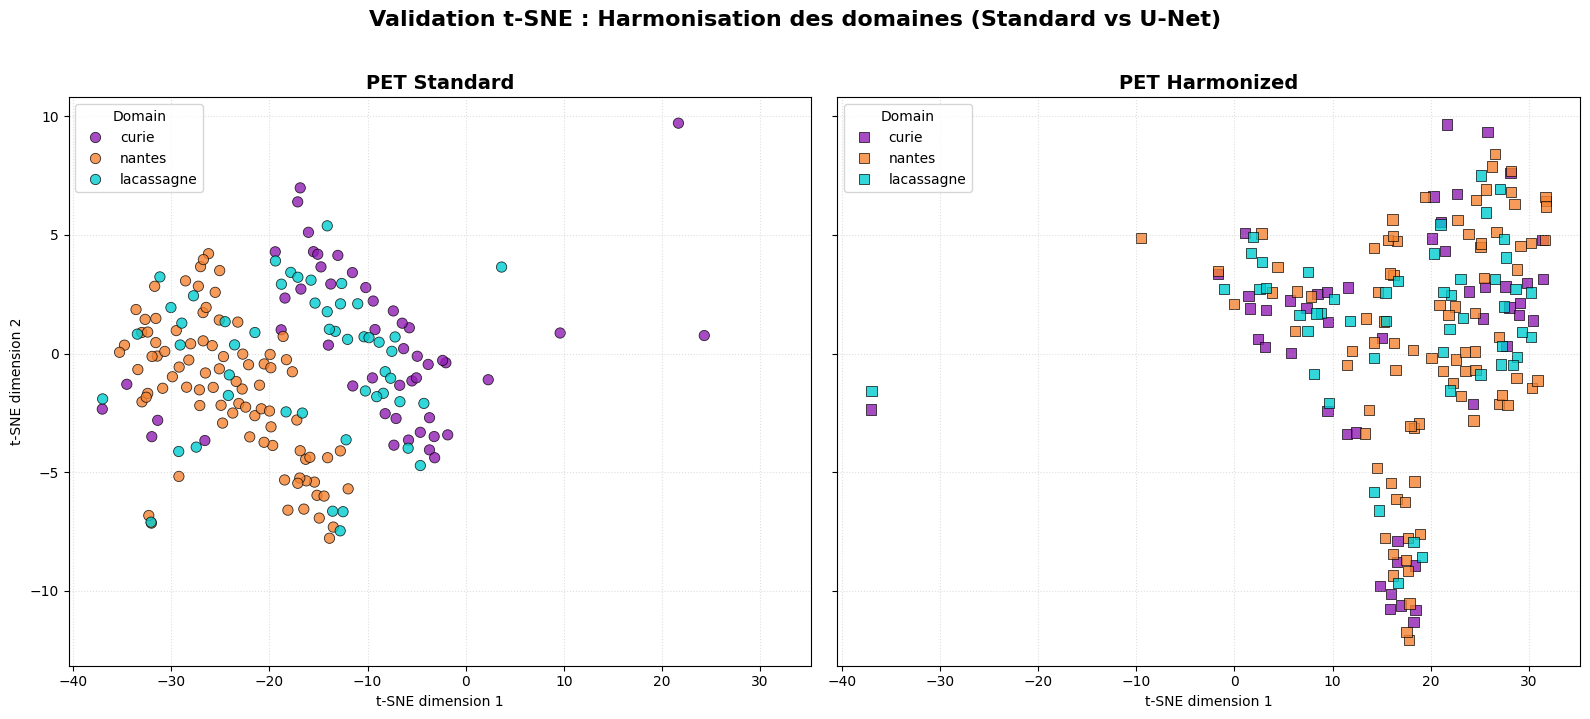

In [17]:
features = df_top30['Feature'].tolist()

selected_features = df_top30[df_top30['Feature'].isin(features)].copy()
print(f"Nombre de features sélectionnées : {len(features)}")

voi_master_df = master_df[(master_df['VOI'] == 'liver') & (master_df['Domain'].isin(['nantes', 'curie', 'lacassagne']))]

df_std = voi_master_df[voi_master_df['Modality'] == 'pet'].copy()
df_harm = voi_master_df[voi_master_df['Modality'] == 'harmonized-pet-vae'].copy()

display_tsne(df_std, df_harm, selected_features)

In [75]:
features = df_top30['Feature'].tolist()

selected_features = df_top30[df_top30['Feature'].isin(features)].copy()
print(f"Nombre de features sélectionnées : {len(features)}")

voi_master_df = master_df[(master_df['VOI'] == 'liver') & (master_df['Domain'].isin(['nantes', 'curie', 'rennes']))]

df_std = voi_master_df[voi_master_df['Modality'] == 'pet'].copy()
df_harm = voi_master_df[voi_master_df['Modality'] == 'harmonized-pet-vae'].copy()
df_all = pd.concat([df_std, df_harm], ignore_index=True)

# display_cov(df_cov)
df_all['COV'] = np.sqrt(df_all['original_firstorder_Variance']) / df_all['original_firstorder_Mean']
df_all['Entropy'] = df_all['original_firstorder_Entropy']

if 'original_firstorder_InterquartileRange' in df_all.columns and 'original_firstorder_Median' in df_all.columns:
    df_all['Robust_COV'] = df_all['original_firstorder_InterquartileRange'] / df_all['original_firstorder_Median']
else:
    df_all['Robust_COV'] = df_all['original_firstorder_MeanAbsoluteDeviation'] / df_all['original_firstorder_Median']

# --- 3. PRÉPARATION GLOBALE (SANS ÉCHANTILLONNAGE) ---
domains = sorted(df_all['Domain'].unique())
modalities = ['pet', 'harmonized-pet-vae']
metrics = ['COV', 'Entropy', 'Robust_COV']
metric_labels = ['COV ($\sigma / \mu$)', 'Entropie (Complexité)', 'Robust COV ($IQR / Median$)']

# On utilise l'intégralité du DataFrame pour l'affichage
df_plot = df_all.copy()

# Pré-calcul des limites par colonne basées sur les 195 patients (1% / 99%)
column_limits = {}
for met in metrics:
    p1, p99 = np.percentile(df_plot[met].dropna(), [1, 99])
    margin = (p99 - p1) * 0.1
    column_limits[met] = (p1 - margin, p99 + margin)



Nombre de features sélectionnées : 30


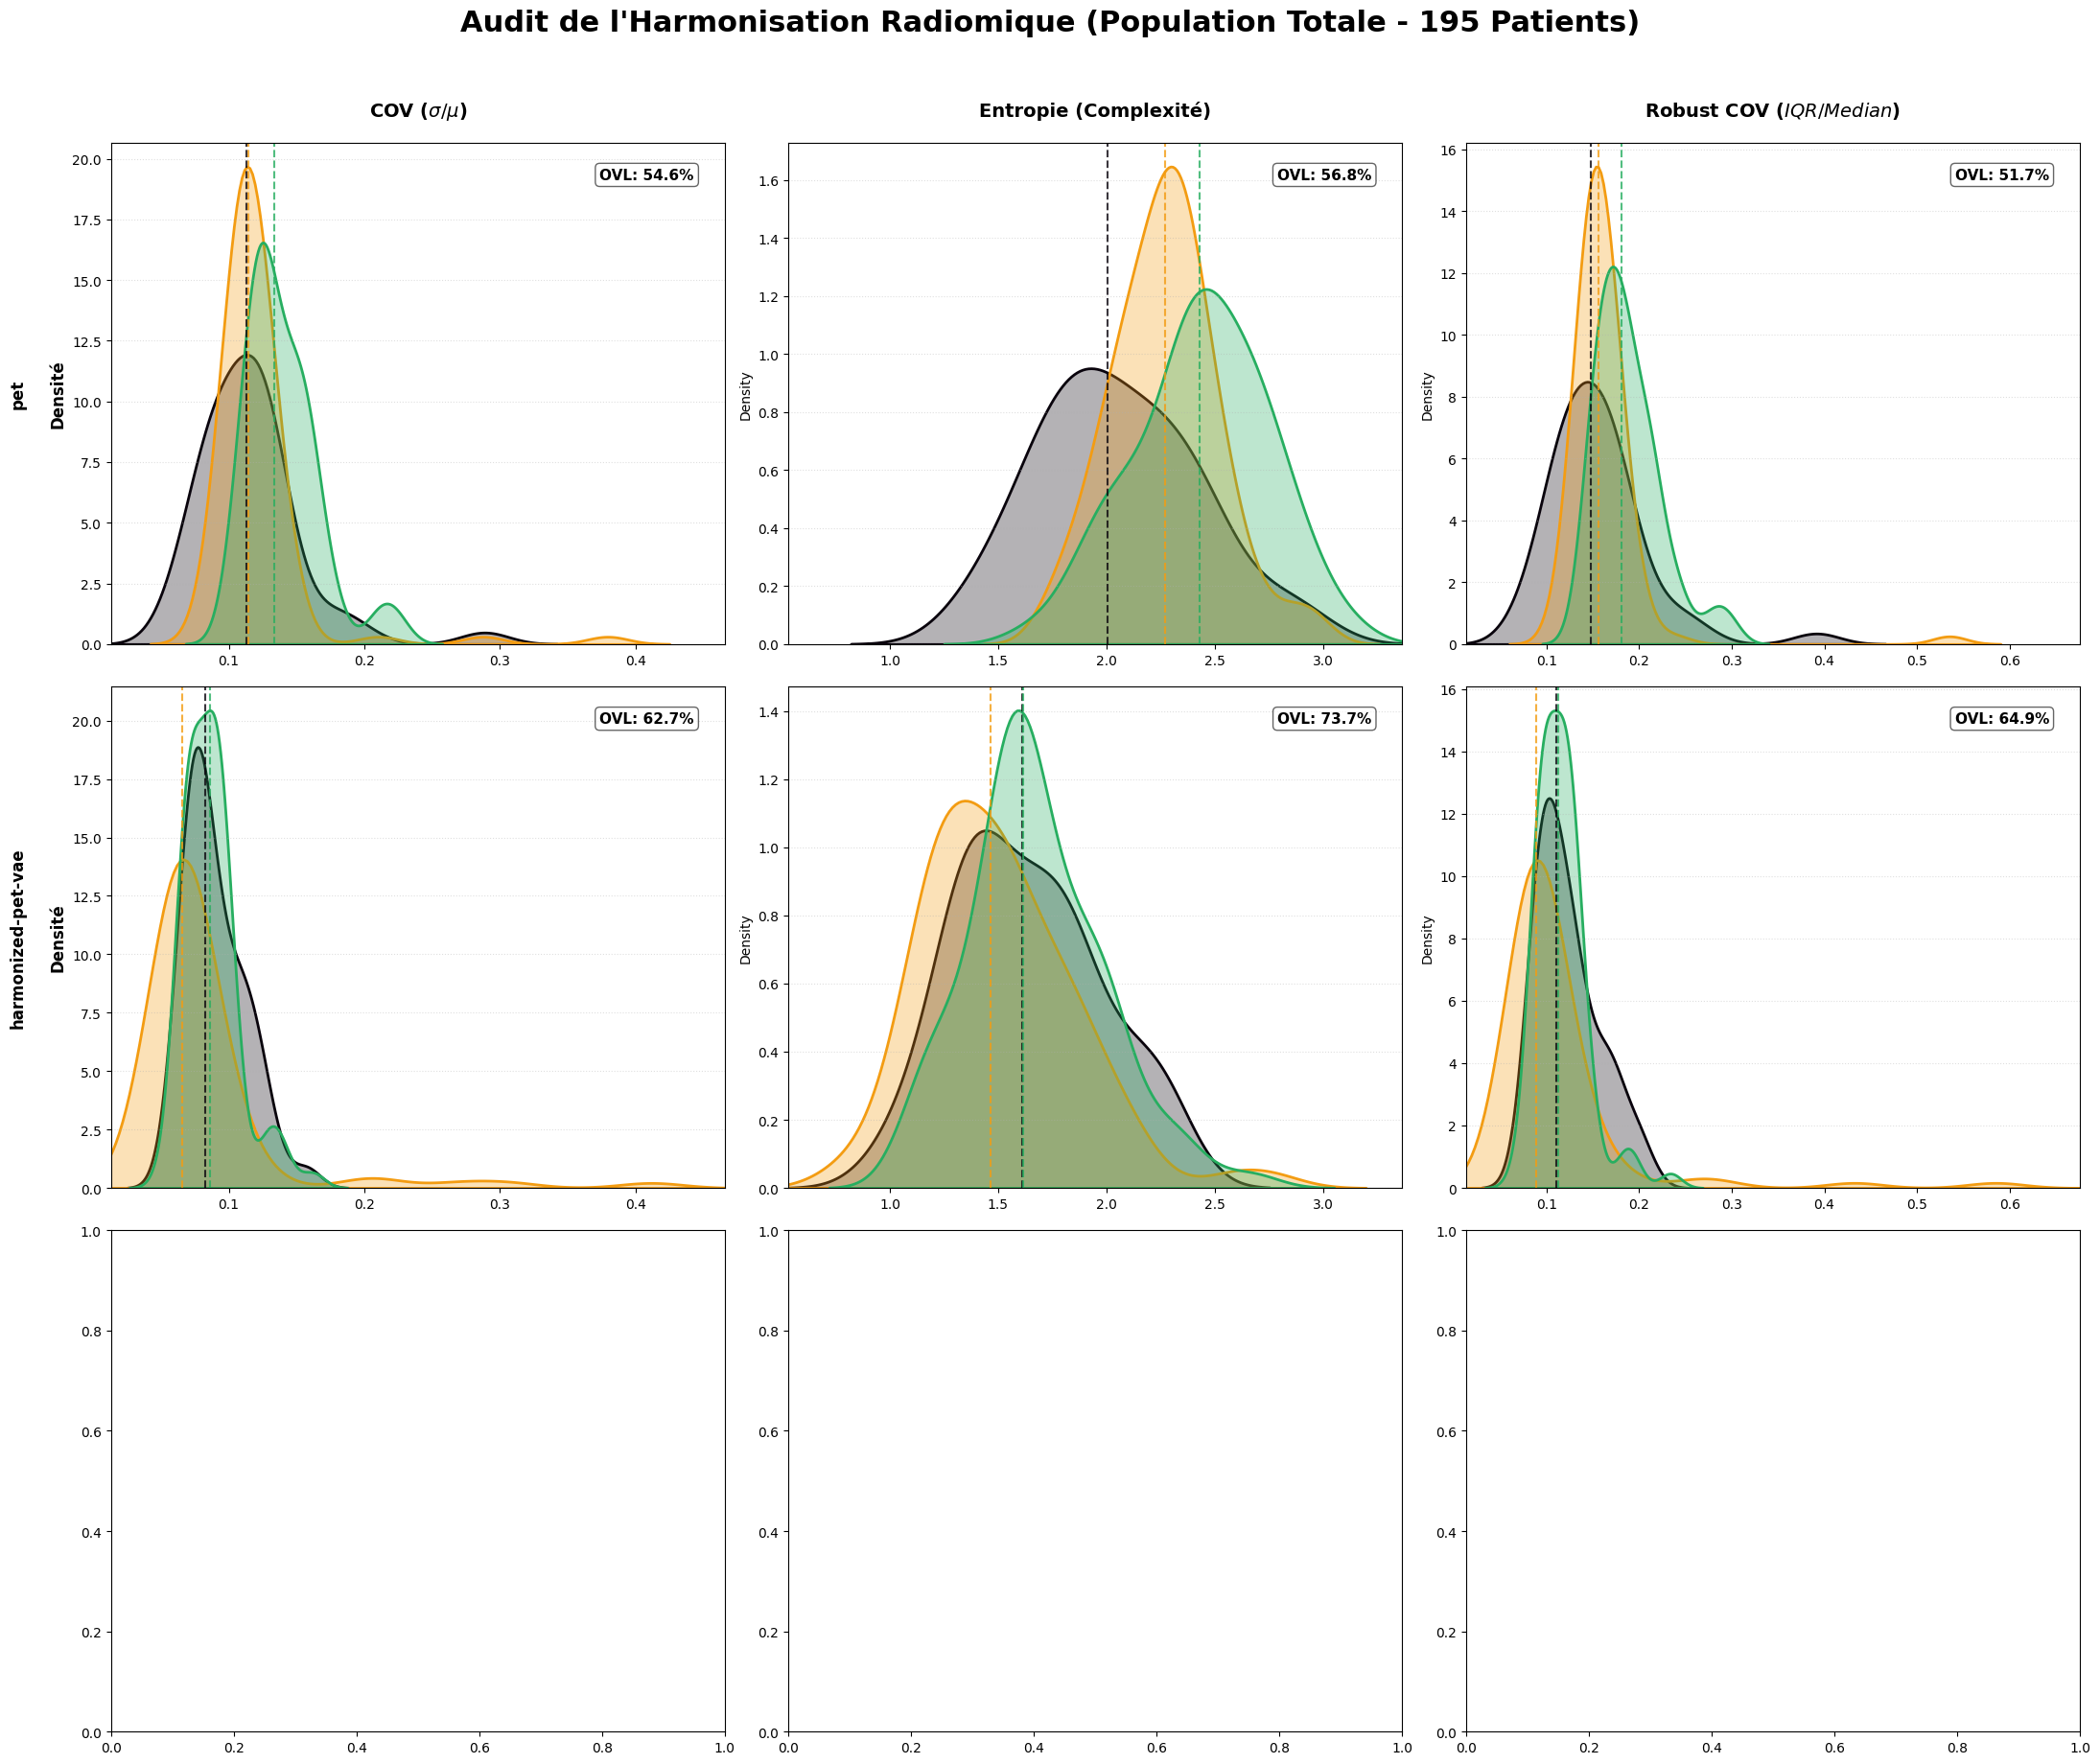

In [76]:
# --- 4. TRACÉ DE LA MATRICE 3x3 ---
fig, axes = plt.subplots(3, 3, figsize=(22, 18))
palette = {
    'a100': '#E74C3C', 
    'chb': '#3498DB', 
    'rennes': '#27AE60', 
    'nice': '#9B59B6',
    'nantes': '#F39C12',
    'curie': "#09030C",
}

for row, mod in enumerate(modalities):
    for col, met in enumerate(metrics):
        ax = axes[row, col]
        df_mod = df_plot[df_plot['Modality'] == mod]
        
        # Bornes globales pour le filtrage des outliers
        p1_global, p99_global = np.percentile(df_plot[met].dropna(), [1, 99])
        
        dist_data = {}
        for d in domains:
            vals = df_mod[df_mod['Domain'] == d][met].dropna().values
            # Filtrage des percentiles extrêmes pour la clarté visuelle
            filtered_vals = vals[(vals >= p1_global) & (vals <= p99_global)]
            if len(filtered_vals) > 0:
                dist_data[d] = filtered_vals

        # Calcul de l'overlap sur la population totale filtrée
        ovl_score = calculate_ovl(dist_data)
        
        # Affichage des courbes KDE
        for d, vals in dist_data.items():
            sns.kdeplot(vals, ax=ax, fill=True, color=palette[d], 
                        label=f"{d} (n={len(vals)})", alpha=0.3, linewidth=2)
            # Ligne verticale sur la Médiane
            ax.axvline(np.median(vals), color=palette[d], linestyle='--', alpha=0.8)
        
        # Verrouillage des axes X par métrique
        ax.set_xlim(column_limits[met])
        
        # Annotations et style
        if col == 0: ax.set_ylabel(f"{mod.replace('_', ' ')}\n\nDensité", fontsize=12, fontweight='bold')
        if row == 0: ax.set_title(metric_labels[col], fontsize=14, pad=20, fontweight='black')
        
        ax.text(0.95, 0.95, f"OVL: {ovl_score:.1f}%", transform=ax.transAxes, 
                ha='right', va='top', fontsize=11, fontweight='bold', 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))
        
        ax.grid(axis='y', linestyle=':', alpha=0.4)
        if row == 2: ax.set_xlabel(metric_labels[col])

plt.suptitle("Audit de l'Harmonisation Radiomique (Population Totale - 195 Patients)", 
            fontsize=22, y=1.02, fontweight='black')
plt.tight_layout()
plt.show()